# Problem Statement - Decide what you want to forecast


- Total daily demand across the business
- Daily demand for one product
- Daily demand for one product in one store/country


# Step 1: Load and inspect the raw data

Understanding- What columns exist
- Which column is the date
- Which column is the quantity sold
- Are there missing values
- Are there cancelled orders or returns

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Demand_Forecasting_Project_Online Retail.xlsx")
df.head()

,InvoiceNo,Product_id,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,Rockaway
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,Rockaway
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,Rockaway
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,Rockaway
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,Rockaway


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   Product_id   541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# Step 2: Clean the raw transactional data

**These steps can be done in sql, but i have done in pandas**

- Convert date column to datetime if not already present using pd.to_datetime , df.column = pd.to_datetime(df.column)
- Reason, Forecasting needs time-aware data. Dates must be real datetime objects, not text

- Remove cancelled orders, since cancellations are not real demand and we want actual customer purchases only

In [6]:
### In the dataset, cancelled invoices often start with C.

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [7]:
### Remove invalid quantities and prices, like '0' or negative in quantity and price

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [ ]:
### there are no columns with missing values

# Step 3: Chosing Forecasting Level - Total Daily Demand (across business)

In [8]:
### aggregating transaction-level data into daily demand
###dt.date extraxts only date part from datetime column
###reset_index() if not used then InvoiceDate column will be treated as index column

daily = df.groupby(df["InvoiceDate"].dt.date)["Quantity"].sum().reset_index()

In [9]:
daily.head()

,InvoiceDate,Quantity
0,2010-12-01,26919
1,2010-12-02,31329
2,2010-12-03,16199
3,2010-12-05,16450
4,2010-12-06,21795


In [10]:
###renaming the columns

daily.columns=["date","demand"]
daily.head()

,date,demand
0,2010-12-01,26919
1,2010-12-02,31329
2,2010-12-03,16199
3,2010-12-05,16450
4,2010-12-06,21795


# Step 4: Make the time series continuous

In [11]:
#### there should be a continous time series column, even if the date has no sales/'0' demand
#### model expects continous time column, with breaks in between, forecast may not be accurate since the model might miss out on learning patterns(weekends missing data)
#### we use lag_1/lag_7, if data is missing there then lag value becomes incorrect and predictions become unreliable, 
#### model might Overestimate or underestimate


daily["date"]= pd.to_datetime(daily["date"])

In [12]:
### creating a dataframe with every single date from start date till end, one row per day.

full_dates = pd.DataFrame({
    "date": pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")})

In [13]:
#### merging dates columnd to 'daily' df

daily = full_dates.merge(daily, on="date", how="left")

In [14]:
daily.head() #####the date 4th dec was missing earlier, which is now included with NaN as demand value

,date,demand
0,2010-12-01,26919.0
1,2010-12-02,31329.0
2,2010-12-03,16199.0
3,2010-12-04,NaN
4,2010-12-05,16450.0


In [15]:
#### replacing NaN with '0'

daily["demand"] = daily["demand"].fillna(0)

In [16]:
daily.head()

,date,demand
0,2010-12-01,26919.0
1,2010-12-02,31329.0
2,2010-12-03,16199.0
3,2010-12-04,0.0
4,2010-12-05,16450.0


In [19]:
### Moving average

daily["rolling_7"] = daily["demand"].rolling(7).mean()
daily["rolling_30"] = daily["demand"].rolling(30).mean()

## Feature Engineering For Modelling

In [21]:
### Lag features

daily["lag_1"]= daily["demand"].shift(1)
daily["lag_7"]= daily["demand"].shift(7)
daily["lag_14"]= daily["demand"].shift(14)

In [22]:
### lags create missing values on top, so remove them from data

daily = daily.dropna()

In [26]:
### creating weekly aggregates - helps check for weekend spikes

weekly = daily.set_index("date").resample("W")["demand"].sum().reset_index()

In [27]:
### creating monthly aggregates - helps check if demand rises over time, if any peak month

monthly = daily.set_index("date").resample("ME")["demand"].sum().reset_index()

In [30]:
###ensure the date column is in cronological order

daily = daily.sort_values("date").reset_index(drop=True)
daily["date"] = pd.to_datetime(daily["date"])

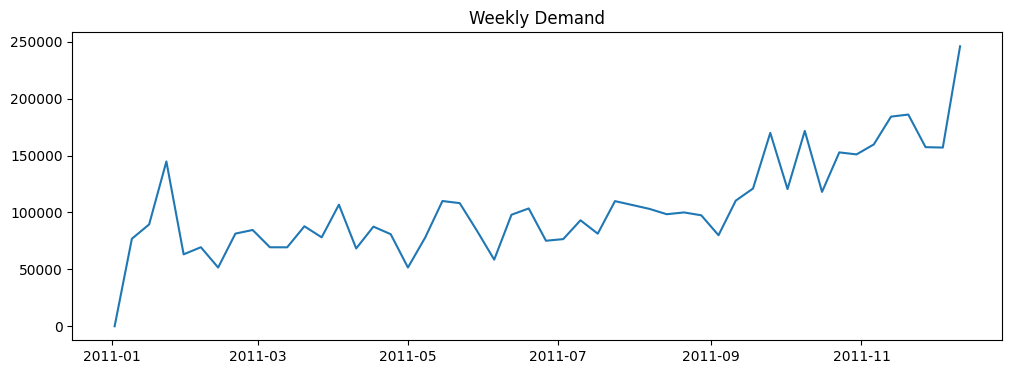

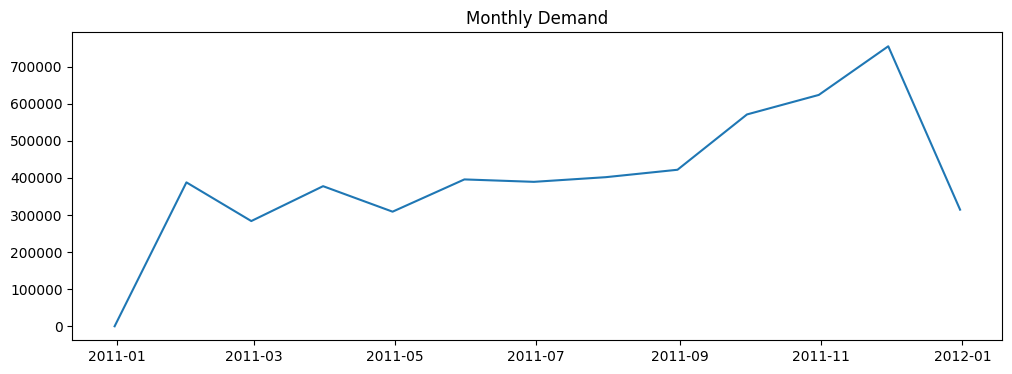

In [29]:
### ploting the weekly and monthly data:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(weekly["date"], weekly["demand"])
plt.title("Weekly Demand")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(monthly["date"], monthly["demand"])
plt.title("Monthly Demand")
plt.show()

Weekly:
- demand fluctuates a lot every week,
- trend is upwards, means growth in sales
- also looks like there is some noise/randomness

Monthly:
- clear upward movement over time, big jump in last few months, no noise
- drop in Jan 2012 which could be not real, in case data is not yet comptely available for Jan

In [28]:
daily.head()

,date,demand,rolling_7,rolling_30,lag_1,lag_7,lag_14
0,2010-12-30,0.0,0.0,11974.633333,0.0,5754.0,29943.0
1,2010-12-31,0.0,0.0,11077.333333,0.0,0.0,16947.0
2,2011-01-01,0.0,0.0,10033.033333,0.0,0.0,0.0
3,2011-01-02,0.0,0.0,9493.066667,0.0,0.0,3799.0
4,2011-01-03,0.0,0.0,9493.066667,0.0,0.0,14940.0


# Step 5: Exploring the series visually

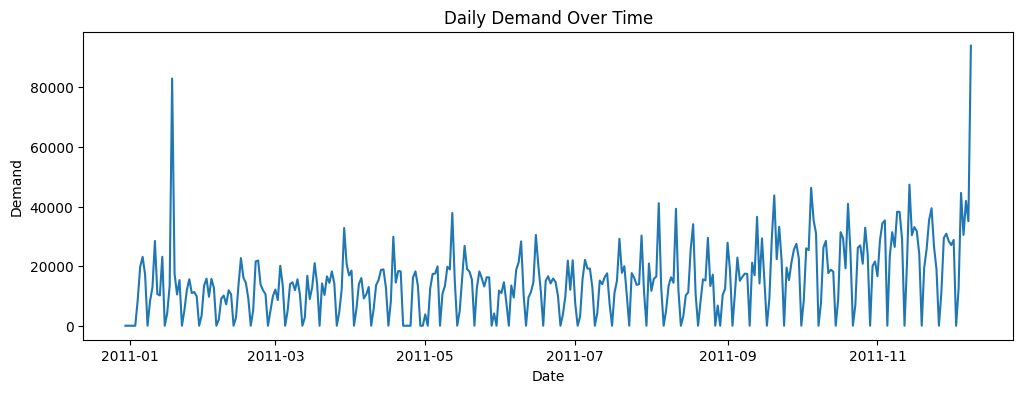

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["demand"])
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

demand is increasing over time

# Step 6 - Test Train Split

In [31]:
### Using the daily series, not weekly/monthly, for the first model

train_size = int(len(daily)*0.8) ##### 80% into train (from original dataset), train_size is the position defining 800 is the split point for test and train

### now use this positioning to slpit the dataset into test and train
train = daily.iloc[:train_size].copy() ### doing the test train on the photocopy of the original dataset, to avoid changes in original dataset
test = daily.iloc[train_size:].copy() ### forecasting to be done only on future dates so last 20% will be under test


# Step 7 - Building a baseline forecast

In [32]:
### predicting future demand using the average of the last 7 days from train data, 

baseline_value = train["demand"].tail(7).mean()

In [33]:
### now using this prediction for all test days-

test["baseline_ma7"] = baseline_value

### this means, the future demand will be similar to recent past (last 7 days)

**So, after splitting the train dataset has 800 rows and test dataset has 200 rows, we are taking last 7 days avg demand from the train dataset. The number/result of which is 'baseline_value' and this is now treated as the forecast_demand column/value for the 200 rows in test dataset.**

# Step 8 - Prepare Prophet input

In [34]:
### profet needs only date and demand column, so we select these two as input from the 800 rows of train data (dataset copy)

prophet_train = train[["date", "demand"]].rename(columns={"date": "ds", "demand": "y"})

# Step 9 - Fit inputs to the model & test the forecast

In [36]:
from prophet import Prophet

model = Prophet()
model.fit(prophet_train)

### model learns trend + weekly seasonality + noise automatically

11:25:10 - cmdstanpy - INFO - Chain [1] start processing
11:25:10 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
### forecasting Test data

future = model.make_future_dataframe(periods=len(test), freq="D") ### model creates dataframe with existing train dates and new future dates
forecast = model.predict(future) ### model predicts for every future date

###now we want to keep only future dates(test forecast) in the dataframe so we can compare with the actual test data that we have

forecast_test = forecast[forecast["ds"].isin(test["date"])][["ds", "yhat"]]

# Step 10-  compare predicted (future forecasted data) with actual test data we have, helps to know if the model works.
**So, Propfet learns the 800 rows demand numbers and predicts the future demand for test 200 rows. Now we have used the 800 rows from train to get forecast numbers for the remaining 200 (test). And we already have the demand for those 200 rows so we can compare both.**

In [39]:
### combining the predicted with actual test data to compare side by side

eval_df = forecast_test.merge(test, left_on="ds", right_on="date", how="inner")

In [41]:
from sklearn.metrics import mean_absolute_error

### MAE (Mean Absolute Error)
mae_prophet = mean_absolute_error(eval_df["demand"], eval_df["yhat"]) ### Average difference between prediction and actual all errors

In [43]:
import numpy as np

### MAPE (Percentage error)
mape_prophet = np.mean(np.abs((eval_df["demand"] - eval_df["yhat"]) / eval_df["demand"])) * 100

In [48]:
print("Prophet MAE:", mae_prophet)
print("Prophet MAPE:", mape_prophet)

Prophet MAE: 8872.90239105223
Prophet MAPE: inf


So if actual demand is 190 and predicted forecats is 180 or 200 then model is off by +_10% , negative or positive doesnt matterm, the number matters. Lesser the number better is the model

# Step 11- Baseline comparison

In [44]:
mae_baseline = mean_absolute_error(test["demand"], test["baseline_ma7"])

In [49]:
print("Baseline MAE:", mae_baseline)

Baseline MAE: 12404.06832298137


SO here Prophet is better because 8872 is < 12404

# Plotting the Comparison baseline vs Prophet

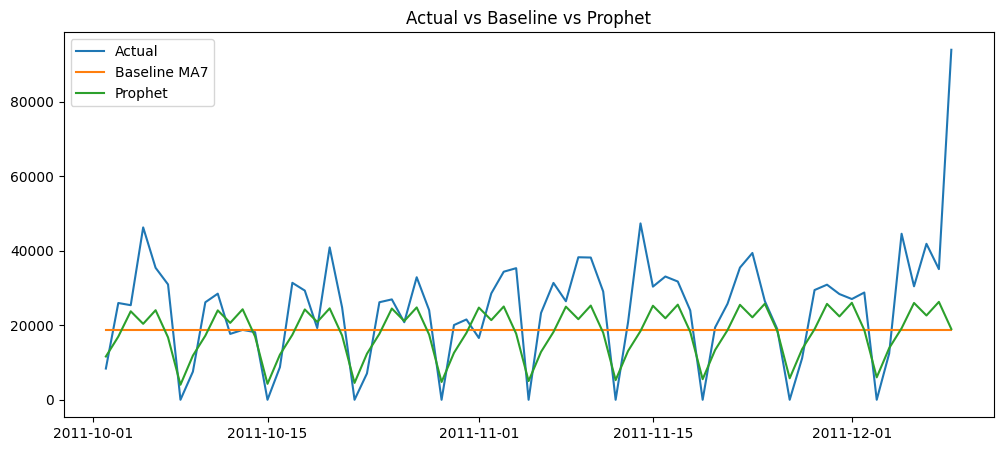

In [50]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], test["demand"], label="Actual")
plt.plot(test["date"], test["baseline_ma7"], label="Baseline MA7")
plt.plot(eval_df["ds"], eval_df["yhat"], label="Prophet")
plt.legend()
plt.title("Actual vs Baseline vs Prophet")
plt.show()

# Checking weekly/monthly comparison

In [51]:
daily.head()

,date,demand,rolling_7,rolling_30,lag_1,lag_7,lag_14
0,2010-12-30,0.0,0.0,11974.633333,0.0,5754.0,29943.0
1,2010-12-31,0.0,0.0,11077.333333,0.0,0.0,16947.0
2,2011-01-01,0.0,0.0,10033.033333,0.0,0.0,0.0
3,2011-01-02,0.0,0.0,9493.066667,0.0,0.0,3799.0
4,2011-01-03,0.0,0.0,9493.066667,0.0,0.0,14940.0


In [52]:
### dnot need to add weekly and monthly to the dataframe - thats only for EDA
### we will create day_of_week and is_weekend to find the weekedn vs weekday comparison

daily["day_of_week"] = daily["date"].dt.dayofweek
daily["is_weekend"] = daily["day_of_week"].isin([5,6]).astype(int)

In [53]:
daily.head()

,date,demand,rolling_7,rolling_30,lag_1,lag_7,lag_14,day_of_week,is_weekend
0,2010-12-30,0.0,0.0,11974.633333,0.0,5754.0,29943.0,3,0
1,2010-12-31,0.0,0.0,11077.333333,0.0,0.0,16947.0,4,0
2,2011-01-01,0.0,0.0,10033.033333,0.0,0.0,0.0,5,1
3,2011-01-02,0.0,0.0,9493.066667,0.0,0.0,3799.0,6,1
4,2011-01-03,0.0,0.0,9493.066667,0.0,0.0,14940.0,0,0


In [54]:
### grouping the data into weekdays and weekends and compared average demand, which showed that weekday demand was significantly higher than weekend demand.

daily.groupby("is_weekend")["demand"].mean()

is_weekend
0    19388.603239
1     4491.346939
Name: demand, dtype: float64

This says weekday demand is 5 times higher than weekend demand

In [ ]:
interview story- "Walk me through your project"

- Data Prep - I started with raw transactional data and aggregated it into daily demand time series.”

handled missing dates
created continuous time series
ensured proper date format

- Feature engineering

“I created time-based features such as rolling averages and lag variables to capture historical demand patterns.”

rolling_7, rolling_30
lag_1, lag_7, lag_14

- Exploratory analysis (VERY IMPORTANT)

“I analyzed demand patterns at daily, weekly, and monthly levels to understand trend and seasonality.”

What you found:

👉 From monthly data:

“Demand showed a clear upward trend over time.”

👉 From weekly behavior (actual data):

“Demand was significantly higher on weekdays (~4x compared to weekends), indicating business-driven purchasing behavior.”

👉 From weekly plot:

“Demand exhibited high variability, indicating short-term fluctuations.”


- Baseline model

“I built a baseline using a 7-day moving average to establish a benchmark.”

- Forecasting model

“I used Prophet to model trend and seasonality and generate future demand predictions.”

- Evaluation

“I evaluated model performance using MAE and MAPE, and compared it against the baseline model.”